# Forage Quantium - Data Analytics Job Simulation

## Name: Parabjot Chander


### Task 2 Broken Down
Select control stores – explore the data and define metrics for your control store selection – think about what would make them a control store. Look at the drivers and make sure you visualise these in a graph to better determine if they are suited. For this piece it may even be worth creating a function to help you. 

Assessment of the trial – this one should give you some interesting insights into each of the stores, check each trial store individually in comparison with the control store to get a clear view of its overall performance. We want to know if the trial stores were successful or not. 

Collate findings – summarise your findings for each store and provide an recommendation that we can share with Julia outlining the impact on sales during the trial period.


In [1]:
# Importing the Libraries 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objs as go 
from plotly.offline import iplot 
from scipy import stats

In [2]:
# Importing the dataset
qvi_df = pd.read_csv("QVI_data.csv")
qvi_df.dtypes

Unnamed: 0            int64
DATE                    str
STORE_NBR             int64
LYLTY_CARD_NBR        int64
TXN_ID                int64
PROD_NBR              int64
PROD_NAME               str
PROD_QTY              int64
TOT_SALES           float64
PACK_SIZE             int64
PROD_BRAND              str
LIFESTAGE               str
PREMIUM_CUSTOMER        str
dtype: object

In [3]:
qvi_df['DATE'] = pd.to_datetime(qvi_df['DATE'], format='%Y-%m-%d')
qvi_df['DATE'].dtype

dtype('<M8[us]')

In [4]:
df = qvi_df[['DATE','STORE_NBR',             
'LYLTY_CARD_NBR',        
'TXN_ID',                
'PROD_NBR',            
'PROD_NAME',               
'PROD_QTY',              
'TOT_SALES',           
'PACK_SIZE',             
'PROD_BRAND',              
'LIFESTAGE',               
'PREMIUM_CUSTOMER']]

df.head(10)

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,PROD_BRAND,LIFESTAGE,PREMIUM_CUSTOMER
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175,Natural,YOUNG SINGLES/COUPLES,Premium
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,175,CCs,MIDAGE SINGLES/COUPLES,Budget
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,170,Smiths,MIDAGE SINGLES/COUPLES,Budget
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly SCreamOnion 175g,5,15.0,175,Smiths,MIDAGE SINGLES/COUPLES,Budget
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHnyJlpno Chili 150g,3,13.8,150,Kettle,MIDAGE SINGLES/COUPLES,Budget
5,2019-05-19,4,4074,2982,57,Old El Paso Salsa Dip Tomato Mild 300g,1,5.1,300,Old,MIDAGE SINGLES/COUPLES,Budget
6,2019-05-16,4,4149,3333,16,Smiths Crinkle Chips Salt Vinegar 330g,1,5.7,330,Smiths,MIDAGE SINGLES/COUPLES,Budget
7,2019-05-16,4,4196,3539,24,Grain Waves Sweet Chilli 210g,1,3.6,210,Grain,MIDAGE SINGLES/COUPLES,Budget
8,2018-08-20,5,5026,4525,42,Doritos Corn Chip Mexican Jalapeno 150g,1,3.9,150,Doritos,MIDAGE SINGLES/COUPLES,Budget
9,2018-08-18,7,7150,6900,52,Grain Waves Sour CreamChives 210G,2,7.2,210,Grain,MIDAGE SINGLES/COUPLES,Budget


In [5]:
df.dtypes

DATE                datetime64[us]
STORE_NBR                    int64
LYLTY_CARD_NBR               int64
TXN_ID                       int64
PROD_NBR                     int64
PROD_NAME                      str
PROD_QTY                     int64
TOT_SALES                  float64
PACK_SIZE                    int64
PROD_BRAND                     str
LIFESTAGE                      str
PREMIUM_CUSTOMER               str
dtype: object

In [6]:
df['STORE_NBR'].value_counts()

STORE_NBR
226    2020
88     1873
93     1832
165    1819
237    1785
       ... 
11        2
252       2
206       2
92        1
76        1
Name: count, Length: 272, dtype: int64

In [7]:
df['SALES_YEAR'] = df['DATE'].dt.year
df['SALES_MONTH'] = df['DATE'].dt.month
df.dtypes

DATE                datetime64[us]
STORE_NBR                    int64
LYLTY_CARD_NBR               int64
TXN_ID                       int64
PROD_NBR                     int64
PROD_NAME                      str
PROD_QTY                     int64
TOT_SALES                  float64
PACK_SIZE                    int64
PROD_BRAND                     str
LIFESTAGE                      str
PREMIUM_CUSTOMER               str
SALES_YEAR                   int32
SALES_MONTH                  int32
dtype: object

In [8]:
df['SALES_MONTH'].value_counts()

SALES_MONTH
12    22835
3     22592
7     22562
8     22410
5     22391
10    22288
1     22161
11    21852
6     21829
4     21766
9     21743
2     20405
Name: count, dtype: int64

In [9]:
df['SALES_YEAR'].value_counts()

SALES_YEAR
2018    133690
2019    131144
Name: count, dtype: int64

#### Selecting the Control Stores 

In [10]:
stores_pre_trial = df[(df['SALES_YEAR'] == 2018) | (df['SALES_MONTH'] == 1)]

In [11]:
# we need to create dataframes for distinguish each trial stores 77, 86, 88 and the control stores 
trial_store_77 = df[df['STORE_NBR'] == 77]

In [12]:
trial_store_86 = df[df['STORE_NBR'] == 86]

In [13]:
trial_store_88 = df[df['STORE_NBR'] == 88]

In [14]:
non_trial_stores = df[(df['STORE_NBR'] != 77) & (df['STORE_NBR'] != 86) & (df['STORE_NBR'] != 88)]

In [15]:
trial_store_77_pre_trial = trial_store_77[(trial_store_77['SALES_YEAR'] == 2018) | (trial_store_77['SALES_MONTH'] == 1)]

In [16]:
trial_store_86_pre_trial = trial_store_86[(trial_store_86['SALES_YEAR'] == 2018) | (trial_store_86['SALES_MONTH'] == 1)]

In [17]:
trial_store_88_pre_trial = trial_store_88[(trial_store_88['SALES_YEAR'] == 2018) | (trial_store_88['SALES_MONTH'] == 1)]

In [18]:
non_trial_stores_pre_trial = non_trial_stores[(non_trial_stores['SALES_YEAR'] == 2018) | (non_trial_stores['SALES_MONTH'] == 1)]

In [19]:
non_trial_stores_metrics = non_trial_stores_pre_trial.groupby(['STORE_NBR', 'SALES_MONTH']).agg({
    'TOT_SALES': 'sum',
    'LYLTY_CARD_NBR': 'nunique',
    'TXN_ID': 'count',
    'PROD_QTY': 'sum'
}).reset_index()
non_trial_stores_metrics.head()

,STORE_NBR,SALES_MONTH,TOT_SALES,LYLTY_CARD_NBR,TXN_ID,PROD_QTY
0,1,1,154.8,35,36,42
1,1,7,206.9,49,52,62
2,1,8,176.1,42,43,54
3,1,9,278.8,59,62,75
4,1,10,188.1,44,45,58


In [20]:
trial_stores_77_metrics = trial_store_77_pre_trial.groupby(['STORE_NBR', 'SALES_MONTH']).agg({
    'TOT_SALES': 'sum',
    'LYLTY_CARD_NBR': 'nunique',
    'TXN_ID': 'count',
    'PROD_QTY': 'sum'
}).reset_index()
trial_stores_77_metrics

,STORE_NBR,SALES_MONTH,TOT_SALES,LYLTY_CARD_NBR,TXN_ID,PROD_QTY
0,77,1,204.4,35,39,65
1,77,7,296.8,51,55,84
2,77,8,255.5,47,48,74
3,77,9,225.2,42,44,70
4,77,10,204.5,37,38,52
5,77,11,245.3,41,44,67
6,77,12,267.3,46,49,72


In [21]:
trial_stores_86_metrics = trial_store_86_pre_trial.groupby(['STORE_NBR', 'SALES_MONTH']).agg({
    'TOT_SALES': 'sum',
    'LYLTY_CARD_NBR': 'nunique',
    'TXN_ID': 'count',
    'PROD_QTY': 'sum'
}).reset_index()
trial_stores_86_metrics

,STORE_NBR,SALES_MONTH,TOT_SALES,LYLTY_CARD_NBR,TXN_ID,PROD_QTY
0,86,1,841.40,94,130,260
1,86,7,892.20,99,126,251
2,86,8,764.05,94,112,215
3,86,9,914.60,103,129,258
4,86,10,948.40,109,138,276
5,86,11,918.00,100,127,254
6,86,12,841.20,98,120,240


In [22]:
trial_stores_88_metrics = trial_store_88_pre_trial.groupby(['STORE_NBR', 'SALES_MONTH']).agg({
    'TOT_SALES': 'sum',
    'LYLTY_CARD_NBR': 'nunique',
    'TXN_ID': 'count',
    'PROD_QTY': 'sum'
}).reset_index()
trial_stores_88_metrics

,STORE_NBR,SALES_MONTH,TOT_SALES,LYLTY_CARD_NBR,TXN_ID,PROD_QTY
0,88,1,1266.4,117,146,292
1,88,7,1310.0,129,153,306
2,88,8,1323.8,131,160,303
3,88,9,1423.0,124,159,318
4,88,10,1352.4,123,158,316
5,88,11,1382.8,130,157,314
6,88,12,1325.2,126,149,298


### Trial Store 77 Comparsion 

#### Monthly Sales

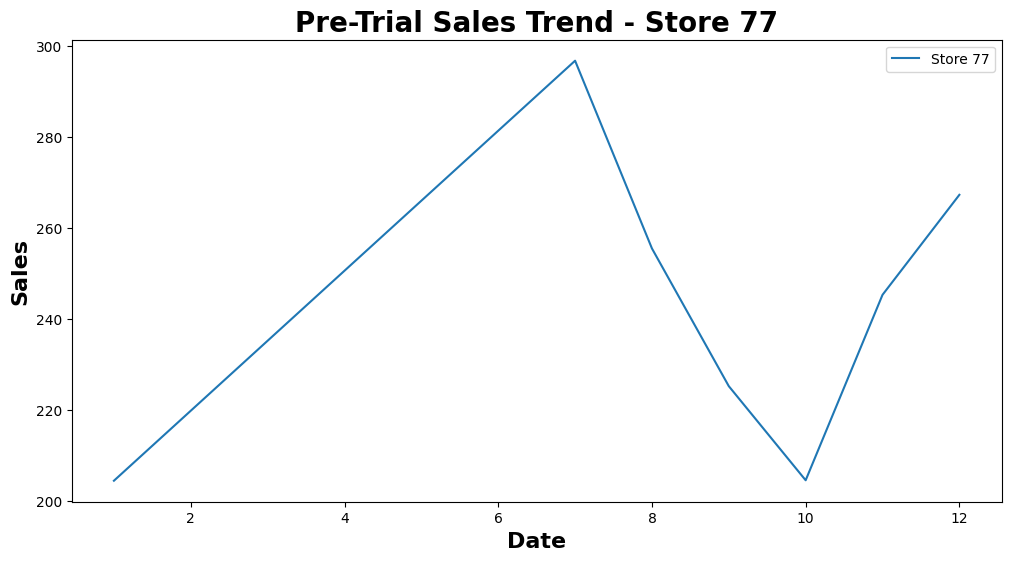

In [25]:
plt.figure(figsize=(12,6))
plt.plot(trial_stores_77_metrics['SALES_MONTH'], trial_stores_77_metrics['TOT_SALES'], label='Store 77')
plt.title('Pre-Trial Sales Trend - Store 77', fontsize=20, fontweight='bold')
plt.xlabel('Date', fontsize=16, fontweight='bold')
plt.ylabel('Sales', fontsize=16, fontweight='bold')
plt.legend()
plt.show()

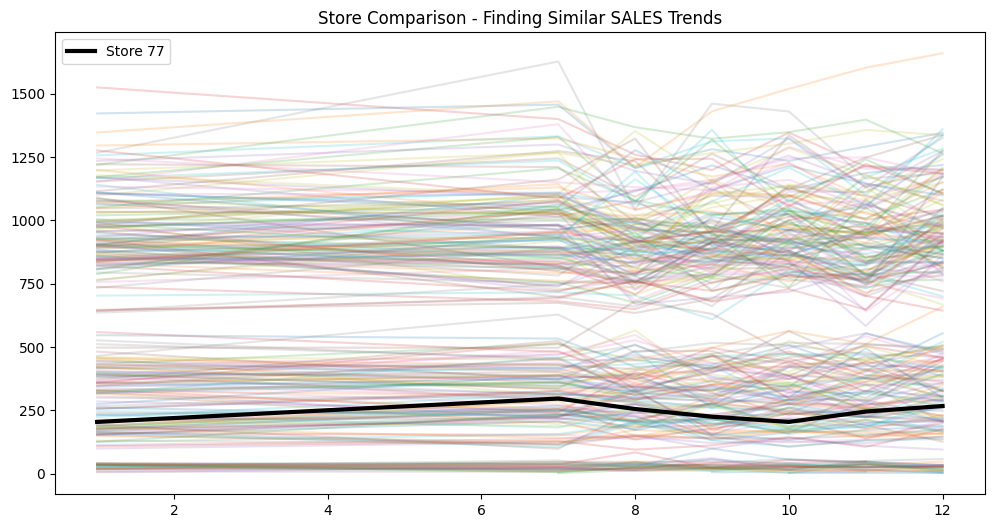

In [26]:
plt.figure(figsize=(12,6))

for store in non_trial_stores_metrics['STORE_NBR'].unique():
    if store != 77:
        store_data = non_trial_stores_metrics[non_trial_stores_metrics['STORE_NBR'] == store]
        plt.plot(store_data['SALES_MONTH'], store_data['TOT_SALES'], alpha=0.2)

# Highlight trial store
plt.plot(trial_stores_77_metrics['SALES_MONTH'], trial_stores_77_metrics['TOT_SALES'],
         color='black', linewidth=3, label='Store 77')

plt.legend()
plt.title('Store Comparison - Finding Similar SALES Trends')
plt.show()

In [27]:
pivot_sales = stores_pre_trial.pivot_table(
    index='SALES_MONTH',
    columns='STORE_NBR',
    values='TOT_SALES'
)
pivot_sales.head()

STORE_NBR,1,2,3,4,5,6,7,8,9,10,...,263,264,265,266,267,268,269,270,271,272
SALES_MONTH,,,,,,,,,,,,,,,,,,,,,
1,4.300000,3.617778,8.691736,9.077381,7.101695,5.164865,8.479130,8.900000,6.051515,6.973016,...,4.260000,4.946000,5.197059,3.232609,3.822222,4.150000,6.808333,6.881290,7.020000,8.460000
7,3.978846,3.678049,8.736957,8.749375,6.766667,5.098039,8.539167,8.874419,5.794000,7.311475,...,4.300000,4.388679,4.588889,3.857576,3.100000,4.307692,7.064748,6.926619,7.415504,8.328846
8,4.095349,4.506977,8.057836,8.341060,6.652679,4.323404,8.548855,8.326087,5.848214,7.029200,...,4.666667,4.958537,4.055357,3.862500,4.980000,5.975000,6.326515,6.517857,6.771287,7.767708
9,4.496774,4.172973,8.584034,8.685507,7.168000,5.465789,8.963281,8.138889,6.266102,6.798561,...,5.450000,4.336957,4.045455,3.475000,4.660000,5.129412,7.145161,6.709524,7.003509,8.463889
10,4.180000,3.902326,8.721849,8.686452,7.457944,5.414815,8.579839,8.628571,6.333333,7.171654,...,4.575000,4.358974,4.286842,4.057143,3.600000,4.950000,7.286486,6.860504,6.929825,8.443137


In [28]:
corr_sales_77 = pivot_sales.corr()[77].sort_values(ascending=False)
corr_sales_77.head()

STORE_NBR
77     1.000000
31     1.000000
11     1.000000
215    0.887080
195    0.804225
Name: 77, dtype: float64

In [30]:
avg_sales = stores_pre_trial.groupby('STORE_NBR')['TOT_SALES'].mean()

comparison = pd.DataFrame({
    'correlation': corr_sales_77,
    'avg_sales': avg_sales
}).sort_values('correlation', ascending=False)

comparison.head(10)

,correlation,avg_sales
STORE_NBR,,
77,1.000000,5.359621
31,1.000000,7.400000
11,1.000000,3.350000
215,0.887080,8.306748
195,0.804225,5.026406
46,0.722829,5.563291
270,0.716361,6.869692
143,0.674554,8.172205
157,0.654122,6.874553


#### Total Customers

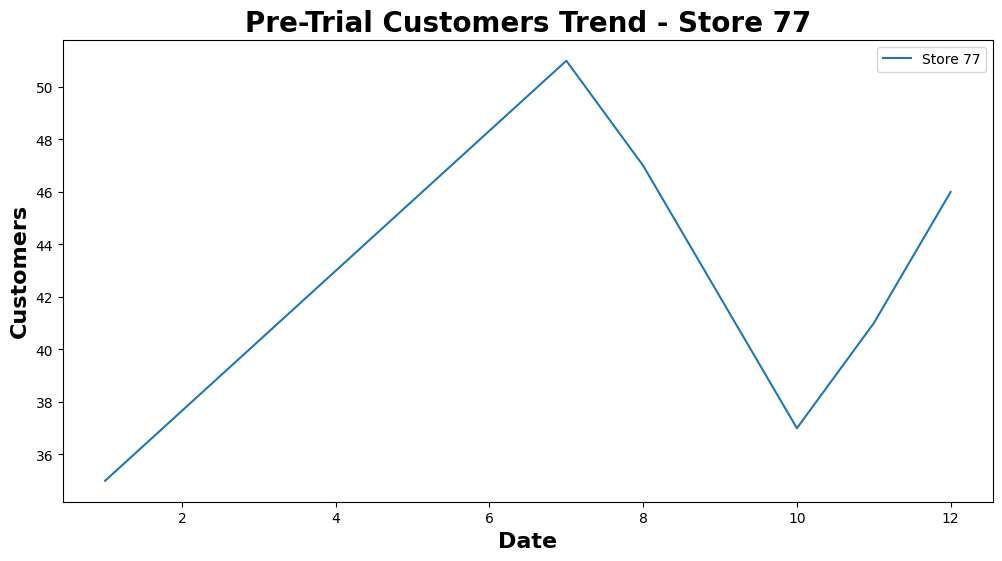

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(trial_stores_77_metrics['SALES_MONTH'], trial_stores_77_metrics['LYLTY_CARD_NBR'], label='Store 77')
plt.title('Pre-Trial Customers Trend - Store 77', fontsize=20, fontweight='bold')
plt.xlabel('Date', fontsize=16, fontweight='bold')
plt.ylabel('Customers', fontsize=16, fontweight='bold')
plt.legend()
plt.show()


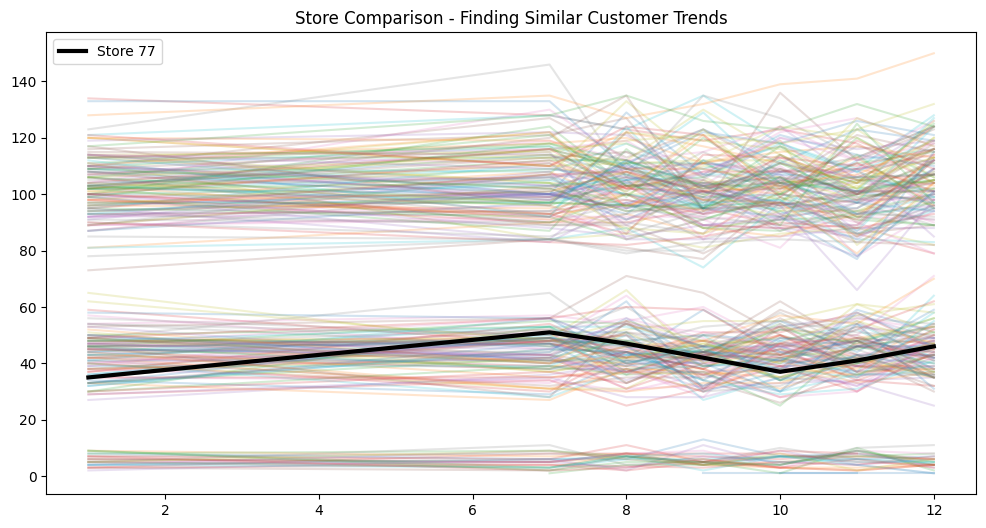

In [35]:
plt.figure(figsize=(12,6))

for store in non_trial_stores_metrics['STORE_NBR'].unique():
    if store != 77:
        store_data = non_trial_stores_metrics[non_trial_stores_metrics['STORE_NBR'] == store]
        plt.plot(store_data['SALES_MONTH'], store_data['LYLTY_CARD_NBR'], alpha=0.2)

# Highlight trial store
plt.plot(trial_stores_77_metrics['SALES_MONTH'], trial_stores_77_metrics['LYLTY_CARD_NBR'],
         color='black', linewidth=3, label='Store 77')

plt.legend()
plt.title('Store Comparison - Finding Similar Customer Trends')
plt.show()

In [36]:
trial_store_77_customers = trial_store_77_pre_trial.groupby(
    ['STORE_NBR', 'SALES_YEAR', 'SALES_MONTH']
)['LYLTY_CARD_NBR'].nunique().reset_index()

In [37]:
other_stores_metrics = non_trial_stores_pre_trial.groupby(
    ['STORE_NBR', 'SALES_YEAR', 'SALES_MONTH']
)['LYLTY_CARD_NBR'].nunique().reset_index()

In [38]:
trial_store_77_customers['YEAR MONTH'] = pd.to_datetime(
    trial_store_77_customers['SALES_YEAR'].astype(str) + '-' +
    trial_store_77_customers['SALES_MONTH'].astype(str) + '-01'
)

other_stores_metrics['YEAR MONTH'] = pd.to_datetime(
    other_stores_metrics['SALES_YEAR'].astype(str) + '-' +
    other_stores_metrics['SALES_MONTH'].astype(str) + '-01'
)

In [39]:
customers_combined = pd.concat([trial_store_77_customers, other_stores_metrics])

In [40]:
pivot_customers = customers_combined.pivot_table(
    index='YEAR MONTH',
    columns='STORE_NBR',
    values='LYLTY_CARD_NBR'
)

In [41]:
corr_77_customers = pivot_customers.corr()[77].sort_values(ascending=False)
corr_77_customers.head()

STORE_NBR
77     1.000000
233    0.990358
119    0.983267
254    0.916208
113    0.901348
Name: 77, dtype: float64

In [42]:
avg_customers = pivot_customers.mean()

comparison = pd.DataFrame({
    'correlation': corr_77_customers,
    'avg_sales': avg_customers
}).sort_values('correlation', ascending=False)

comparison.head()

,correlation,avg_sales
STORE_NBR,,
77,1.000000,42.714286
233,0.990358,42.571429
119,0.983267,98.285714
254,0.916208,36.571429
113,0.901348,99.000000


#### Average Numbers of Transactions Per Customer

In [44]:
trial_store_77_transactions = trial_store_77_pre_trial.groupby(
    ['STORE_NBR', 'SALES_YEAR', 'SALES_MONTH']
)['TXN_ID'].mean().reset_index()

In [45]:
other_stores_transactions = non_trial_stores_pre_trial.groupby(
    ['STORE_NBR', 'SALES_YEAR', 'SALES_MONTH']
)['TXN_ID'].mean().reset_index()

In [46]:
trial_store_77_transactions['YEAR MONTH'] = pd.to_datetime(
    trial_store_77_transactions['SALES_YEAR'].astype(str) + '-' +
    trial_store_77_transactions['SALES_MONTH'].astype(str) + '-01'
)

other_stores_transactions['YEAR MONTH'] = pd.to_datetime(
    other_stores_transactions['SALES_YEAR'].astype(str) + '-' +
    other_stores_transactions['SALES_MONTH'].astype(str) + '-01'
)

In [48]:
combined_transactions = pd.concat([trial_store_77_transactions, other_stores_transactions])

In [50]:
pivot_transactions = combined_transactions.pivot_table(
    index='YEAR MONTH',
    columns='STORE_NBR',
    values='TXN_ID'
)

In [51]:
corr_77_transactions = pivot_transactions.corr()[77].sort_values(ascending=False)
corr_77_transactions.head()

STORE_NBR
77     1.000000
11     1.000000
31     1.000000
37     0.871425
215    0.829934
Name: 77, dtype: float64

In [52]:
avg_transactions = pivot_transactions.mean()

transactions_comparison = pd.DataFrame({
    'correlation': corr_77_transactions,
    'avg_sales': avg_transactions
}).sort_values('correlation', ascending=False)

transactions_comparison.head()

,correlation,avg_sales
STORE_NBR,,
77,1.000000,82529.483574
11,1.000000,10507.500000
31,1.000000,27974.500000
37,0.871425,33729.143140
215,0.829934,214429.171174


#### Control Store selected for Trial Store 77 is 31, they have similar metrics and a high correlation values 

### Trial Store 86 Comparsion

#### Sales Revenue

In [23]:
trial_store_86_sales = trial_store_86_pre_trial.groupby(
    ['STORE_NBR', 'SALES_YEAR', 'SALES_MONTH']
)['TOT_SALES'].sum().reset_index()

In [24]:
non_trial_stores_sales = non_trial_stores_pre_trial.groupby(
    ['STORE_NBR', 'SALES_YEAR', 'SALES_MONTH']
)['TOT_SALES'].sum().reset_index()

In [25]:
trial_store_86_sales['YEAR MONTH'] = pd.to_datetime(
    trial_store_86_sales['SALES_YEAR'].astype(str) + '-' +
    trial_store_86_sales['SALES_MONTH'].astype(str) + '-01'
)

non_trial_stores_sales['YEAR MONTH'] = pd.to_datetime(
    non_trial_stores_sales['SALES_YEAR'].astype(str) + '-' +
    non_trial_stores_sales['SALES_MONTH'].astype(str) + '-01'
)

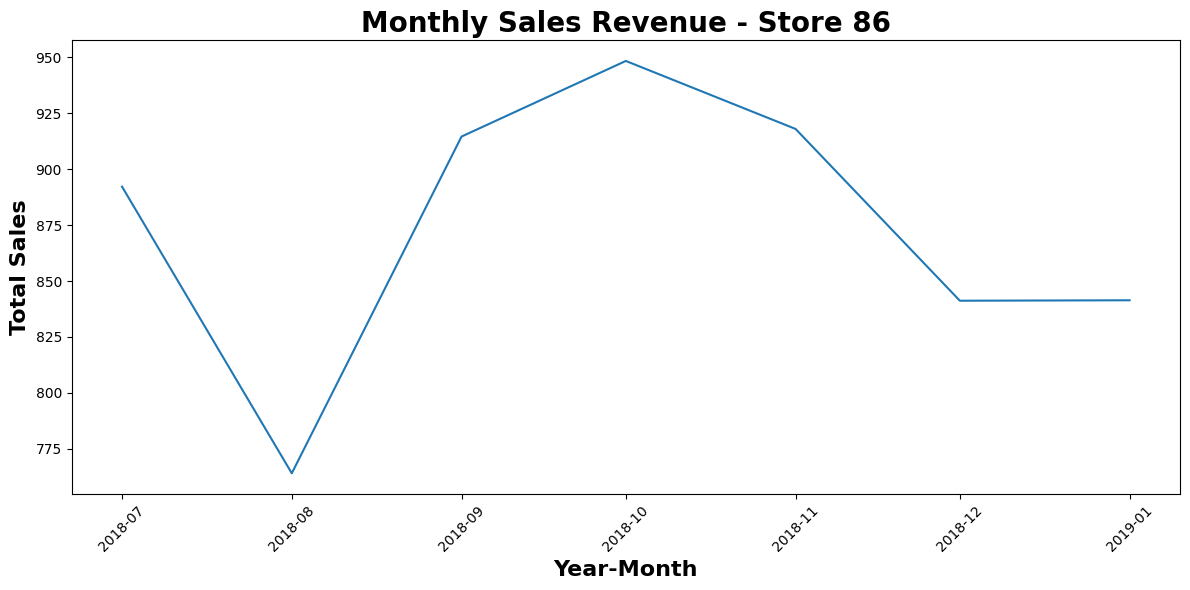

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(trial_store_86_sales['YEAR MONTH'],
        trial_store_86_sales['TOT_SALES'], label='black')

plt.xticks(rotation=45)
plt.xlabel('Year-Month', fontsize=16, fontweight='bold')
plt.ylabel('Total Sales', fontsize=16, fontweight='bold')
plt.title('Monthly Sales Revenue - Store 86', fontsize=20, fontweight='bold')

plt.tight_layout()
plt.show()

In [96]:
combined_sales_86 = pd.concat([trial_store_86_sales, non_trial_stores_sales])

In [97]:
pivot_sales_86 = combined_sales_86.pivot_table(
    index='YEAR MONTH',
    columns='STORE_NBR',
    values='TOT_SALES'
)

In [28]:
corr_86_sales = pivot_sales_86.corr()[86].sort_values(ascending=False)
corr_86_sales.head()

STORE_NBR
31     1.000000
86     1.000000
155    0.877882
132    0.846517
240    0.825066
Name: 86, dtype: float64

In [29]:
avg_sales = pivot_sales_86.mean()

sales_comparison_86 = pd.DataFrame({
    'correlation': corr_86_sales,
    'avg_sales': avg_sales
}).sort_values('correlation', ascending=False)

sales_comparison_86.head()

,correlation,avg_sales
STORE_NBR,,
31,1.000000,7.400000
86,1.000000,874.264286
155,0.877882,901.242857
132,0.846517,38.828571
240,0.825066,398.585714


#### Total Customers

In [86]:
trial_store_86_customers = trial_store_86_pre_trial.groupby(
    ['STORE_NBR', 'SALES_YEAR', 'SALES_MONTH']
)['LYLTY_CARD_NBR'].nunique().reset_index()

trial_store_86_customers

,STORE_NBR,SALES_YEAR,SALES_MONTH,LYLTY_CARD_NBR
0,86,2018,7,99
1,86,2018,8,94
2,86,2018,9,103
3,86,2018,10,109
4,86,2018,11,100
5,86,2018,12,98
6,86,2019,1,94


In [87]:
non_trial_stores_86_customers = non_trial_stores_pre_trial.groupby(
    ['STORE_NBR', 'SALES_YEAR', 'SALES_MONTH']
)['LYLTY_CARD_NBR'].nunique().reset_index()

In [88]:
trial_store_86_customers['YEAR MONTH'] = pd.to_datetime(
    trial_store_86_customers['SALES_YEAR'].astype(str) + '-' +
    trial_store_86_customers['SALES_MONTH'].astype(str) + '-01'
)

non_trial_stores_86_customers['YEAR MONTH'] = pd.to_datetime(
    non_trial_stores_86_customers['SALES_YEAR'].astype(str) + '-' +
    non_trial_stores_86_customers['SALES_MONTH'].astype(str) + '-01'
)

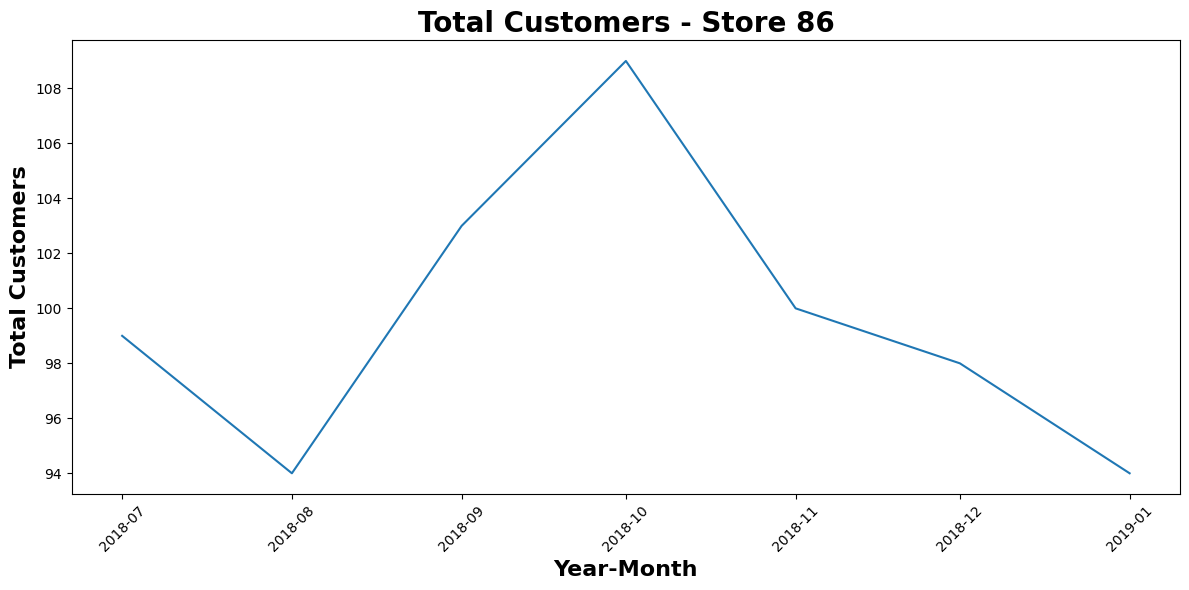

In [89]:
plt.figure(figsize=(12,6))

plt.plot(trial_store_86_customers['YEAR MONTH'],
        trial_store_86_customers['LYLTY_CARD_NBR'], label='black')

plt.xticks(rotation=45)
plt.xlabel('Year-Month', fontsize=16, fontweight='bold')
plt.ylabel('Total Customers', fontsize=16, fontweight='bold')
plt.title('Total Customers - Store 86', fontsize=20, fontweight='bold')

plt.tight_layout()
plt.show()

In [90]:
combined_customers_86 = pd.concat([trial_store_86_customers, non_trial_stores_86_customers])

In [91]:
pivot_customers_86 = combined_customers_86.pivot_table(
    index='YEAR MONTH',
    columns='STORE_NBR',
    values='LYLTY_CARD_NBR'
)

In [92]:
corr_86_customers = pivot_customers_86.corr()[86].sort_values(ascending=False)
corr_86_customers.head()

STORE_NBR
86     1.000000
155    0.942876
114    0.855339
260    0.846502
176    0.796380
Name: 86, dtype: float64

In [93]:
avg_customers = pivot_customers_86.mean()

customers_comparison_86 = pd.DataFrame({
    'correlation': corr_86_customers,
    'avg_customers': avg_customers
}).sort_values('correlation', ascending=False)

customers_comparison_86.head()

,correlation,avg_customers
STORE_NBR,,
86,1.000000,99.571429
155,0.942876,99.571429
114,0.855339,105.857143
260,0.846502,47.714286
176,0.796380,41.571429


#### Average Number of Transactions Per Customer


In [67]:
trial_store_86_transactions = trial_store_86_pre_trial.groupby(['STORE_NBR','SALES_YEAR', 'SALES_MONTH']).agg({
    'TXN_ID': 'count',                 
    'LYLTY_CARD_NBR': 'nunique'       
}).rename(columns={
    'TXN_ID': 'TOTAL_TXN',
    'LYLTY_CARD_NBR': 'NUM_CUSTOMERS'
}).reset_index()

trial_store_86_transactions['AVG_TXN_PER_CUSTOMER'] = (
    trial_store_86_transactions['TOTAL_TXN'] / trial_store_86_transactions['NUM_CUSTOMERS']
)

trial_store_86_transactions

,STORE_NBR,SALES_YEAR,SALES_MONTH,TOTAL_TXN,NUM_CUSTOMERS,AVG_TXN_PER_CUSTOMER
0,86,2018,7,126,99,1.272727
1,86,2018,8,112,94,1.191489
2,86,2018,9,129,103,1.252427
3,86,2018,10,138,109,1.266055
4,86,2018,11,127,100,1.270000
5,86,2018,12,120,98,1.224490
6,86,2019,1,130,94,1.382979


In [68]:
non_trial_stores_86_transactions = non_trial_stores_pre_trial.groupby(['STORE_NBR','SALES_YEAR', 'SALES_MONTH']).agg({
    'TXN_ID': 'count',                 
    'LYLTY_CARD_NBR': 'nunique'       
}).rename(columns={
    'TXN_ID': 'TOTAL_TXN',
    'LYLTY_CARD_NBR': 'NUM_CUSTOMERS'
}).reset_index()

non_trial_stores_86_transactions['AVG_TXN_PER_CUSTOMER'] = (
    non_trial_stores_86_transactions['TOTAL_TXN'] / non_trial_stores_86_transactions['NUM_CUSTOMERS']
)

In [69]:
trial_store_86_transactions['YEAR MONTH'] = pd.to_datetime(
    trial_store_86_transactions['SALES_YEAR'].astype(str) + '-' +
    trial_store_86_transactions['SALES_MONTH'].astype(str) + '-01'
)

non_trial_stores_86_transactions['YEAR MONTH'] = pd.to_datetime(
    non_trial_stores_86_transactions['SALES_YEAR'].astype(str) + '-' +
    non_trial_stores_86_transactions['SALES_MONTH'].astype(str) + '-01'
)

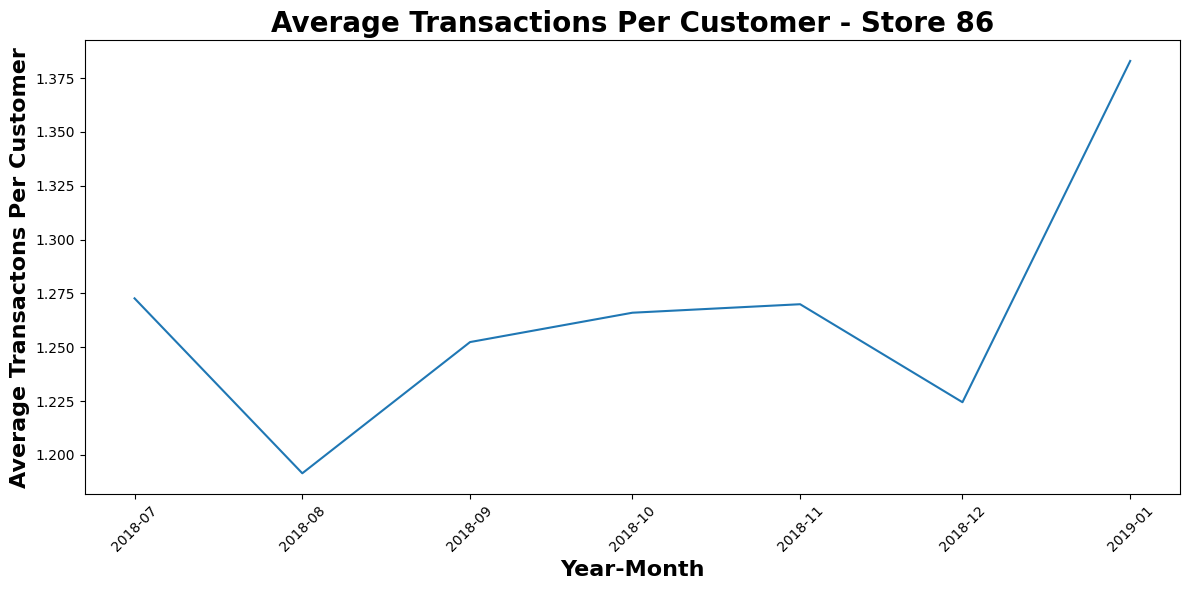

In [71]:
plt.figure(figsize=(12,6))

plt.plot(trial_store_86_transactions['YEAR MONTH'],
        trial_store_86_transactions['AVG_TXN_PER_CUSTOMER'])

plt.xticks(rotation=45)
plt.xlabel('Year-Month', fontsize=16, fontweight='bold')
plt.ylabel('Average Transactons Per Customer', fontsize=16, fontweight='bold')
plt.title('Average Transactions Per Customer - Store 86', fontsize=20, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
combined_transactions_86 = pd.concat([trial_store_86_transactions, non_trial_stores_86_transactions])

In [ ]:
pivot_transactions_86 = combined_transactions_86.pivot_table(
    index='YEAR MONTH',
    columns='STORE_NBR',
    values='AVG_TXN_PER_CUSTOMER'
)

In [74]:
corr_86_transactions = pivot_transactions_86.corr()[86].sort_values(ascending=False)
corr_86_transactions.head()

STORE_NBR
86     1.000000
118    0.891259
13     0.884821
244    0.869646
144    0.837251
Name: 86, dtype: float64

In [75]:
avg_transactions_86 = pivot_transactions_86.mean()

transactions_comparison_86 = pd.DataFrame({
    'correlation': corr_86_customers,
    'avg_customers': avg_transactions_86
}).sort_values('correlation', ascending=False)

transactions_comparison_86.head()

,correlation,avg_customers
STORE_NBR,,
86,1.000000,1.265738
155,0.942876,1.302841
114,0.855339,1.265577
260,0.846502,1.050919
176,0.796380,1.033190


#### Control Store selected for Trial Store 86 is 155, they have similar metrics and a high correlation values

### Trial Store 88 Comparsion 

#### Sales Revenue

In [76]:
trial_store_88_sales = trial_store_88_pre_trial.groupby(
    ['STORE_NBR', 'SALES_YEAR', 'SALES_MONTH']
)['TOT_SALES'].sum().reset_index()

In [78]:
non_trial_stores_88_sales = non_trial_stores_pre_trial.groupby(
    ['STORE_NBR', 'SALES_YEAR', 'SALES_MONTH']
)['TOT_SALES'].sum().reset_index()

In [79]:
trial_store_88_sales['YEAR MONTH'] = pd.to_datetime(
    trial_store_88_sales['SALES_YEAR'].astype(str) + '-' +
    trial_store_88_sales['SALES_MONTH'].astype(str) + '-01'
)

non_trial_stores_88_sales['YEAR MONTH'] = pd.to_datetime(
    non_trial_stores_88_sales['SALES_YEAR'].astype(str) + '-' +
    non_trial_stores_88_sales['SALES_MONTH'].astype(str) + '-01'
)

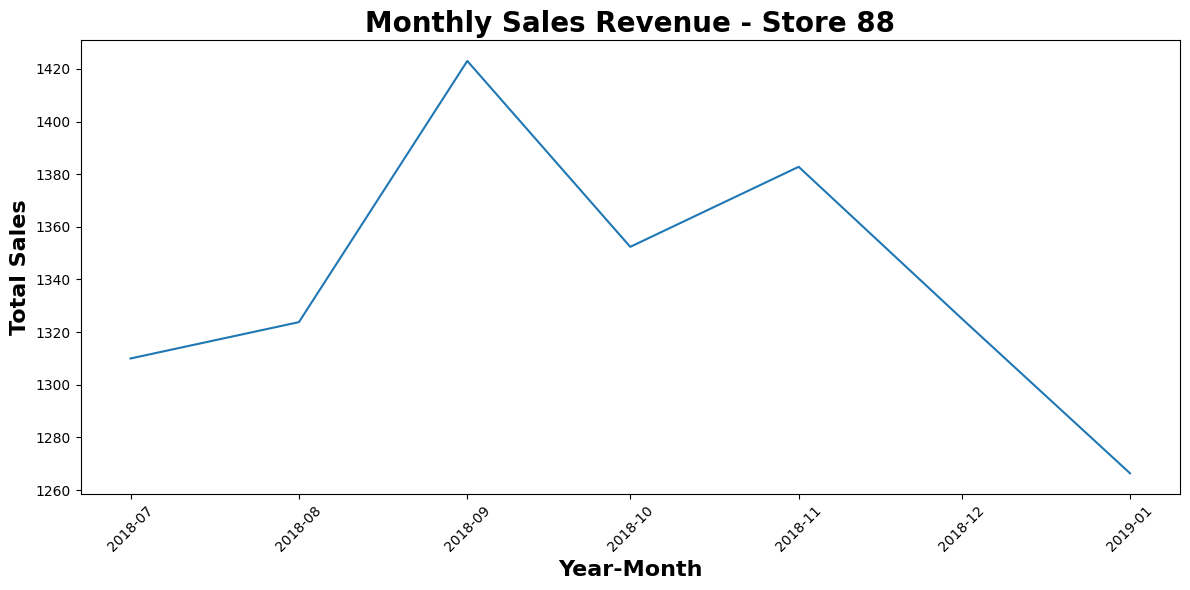

In [81]:
plt.figure(figsize=(12,6))

plt.plot(trial_store_88_sales['YEAR MONTH'],
        trial_store_88_sales['TOT_SALES'], label='black')

plt.xticks(rotation=45)
plt.xlabel('Year-Month', fontsize=16, fontweight='bold')
plt.ylabel('Total Sales', fontsize=16, fontweight='bold')
plt.title('Monthly Sales Revenue - Store 88', fontsize=20, fontweight='bold')

plt.tight_layout()
plt.show()

In [98]:
combined_sales_88 = pd.concat([trial_store_88_sales, non_trial_stores_88_sales])

In [99]:
pivot_sales_88 = combined_sales_88.pivot_table(
    index='YEAR MONTH',
    columns='STORE_NBR',
    values='TOT_SALES'
)

In [100]:
corr_88_sales = pivot_sales_88.corr()[88].sort_values(ascending=False)
corr_88_sales.head()

STORE_NBR
88     1.000000
159    0.903186
204    0.885774
134    0.864293
1      0.813636
Name: 88, dtype: float64

In [102]:
median_sales_88 = pivot_sales_88.median()

sales_comparison_88 = pd.DataFrame({
    'correlation': corr_88_sales,
    'median_sales': median_sales_88
}).sort_values('correlation', ascending=False)

sales_comparison_88.head()

,correlation,median_sales
STORE_NBR,,
88,1.000000,1325.20
159,0.903186,21.00
204,0.885774,39.90
134,0.864293,432.65
1,0.813636,189.60


#### Total Customers

In [104]:
trial_store_88_customers = trial_store_88_pre_trial.groupby(
    ['STORE_NBR', 'SALES_YEAR', 'SALES_MONTH']
)['LYLTY_CARD_NBR'].nunique().reset_index()
trial_store_88_customers

,STORE_NBR,SALES_YEAR,SALES_MONTH,LYLTY_CARD_NBR
0,88,2018,7,129
1,88,2018,8,131
2,88,2018,9,124
3,88,2018,10,123
4,88,2018,11,130
5,88,2018,12,126
6,88,2019,1,117


In [105]:
non_trial_stores_88_customers = non_trial_stores_pre_trial.groupby(
    ['STORE_NBR', 'SALES_YEAR', 'SALES_MONTH']
)['LYLTY_CARD_NBR'].nunique().reset_index()

In [106]:
trial_store_88_customers['YEAR MONTH'] = pd.to_datetime(
    trial_store_88_customers['SALES_YEAR'].astype(str) + '-' +
    trial_store_88_customers['SALES_MONTH'].astype(str) + '-01'
)

non_trial_stores_88_customers['YEAR MONTH'] = pd.to_datetime(
    non_trial_stores_88_customers['SALES_YEAR'].astype(str) + '-' +
    non_trial_stores_88_customers['SALES_MONTH'].astype(str) + '-01'
)

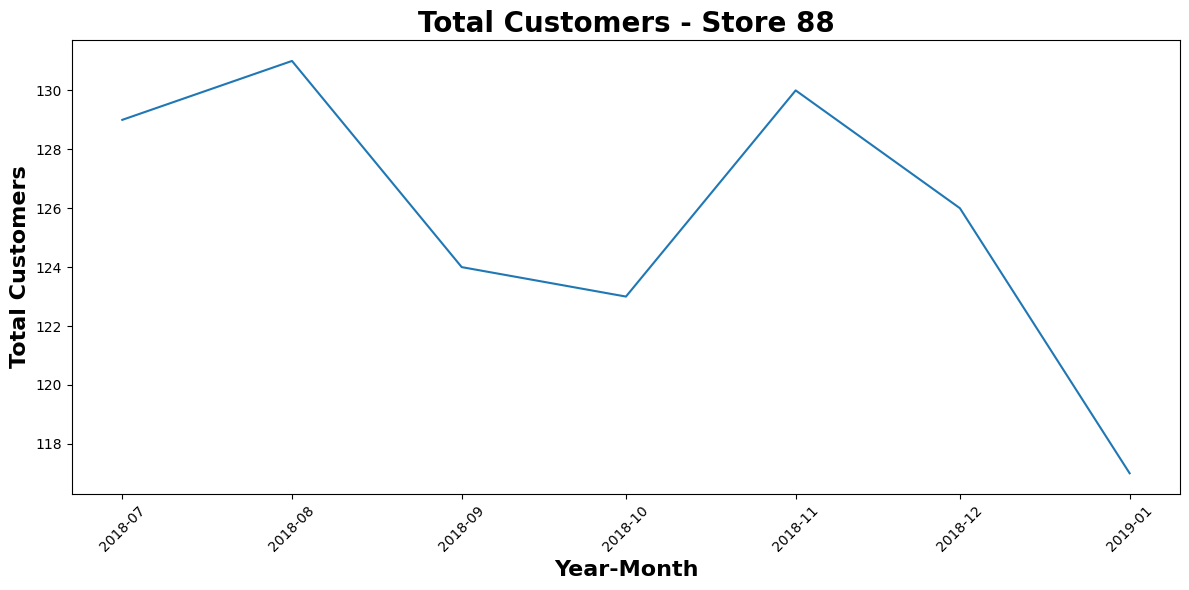

In [107]:
plt.figure(figsize=(12,6))

plt.plot(trial_store_88_customers['YEAR MONTH'],
        trial_store_88_customers['LYLTY_CARD_NBR'], label='black')

plt.xticks(rotation=45)
plt.xlabel('Year-Month', fontsize=16, fontweight='bold')
plt.ylabel('Total Customers', fontsize=16, fontweight='bold')
plt.title('Total Customers - Store 88', fontsize=20, fontweight='bold')

plt.tight_layout()
plt.show()

In [108]:
combined_customers_88 = pd.concat([trial_store_88_customers, non_trial_stores_88_customers])

In [109]:
pivot_customers_88 = combined_customers_88.pivot_table(
    index='YEAR MONTH',
    columns='STORE_NBR',
    values='LYLTY_CARD_NBR'
)

In [110]:
corr_88_customers = pivot_customers_88.corr()[88].sort_values(ascending=False)
corr_88_customers.head()

STORE_NBR
88     1.000000
237    0.947326
14     0.942976
178    0.939466
35     0.899594
Name: 88, dtype: float64

In [111]:
avg_customers_88 = pivot_customers_88.mean()

customers_comparison_88 = pd.DataFrame({
    'correlation': corr_88_customers,
    'avg_customers': avg_customers_88
}).sort_values('correlation', ascending=False)

customers_comparison_88.head()

,correlation,avg_customers
STORE_NBR,,
88,1.000000,125.714286
237,0.947326,126.428571
14,0.942976,6.571429
178,0.939466,103.571429
35,0.899594,33.714286


#### Average Transactions Per Customer

In [112]:
trial_store_88_transactions = trial_store_88_pre_trial.groupby(['STORE_NBR','SALES_YEAR', 'SALES_MONTH']).agg({
    'TXN_ID': 'count',                 
    'LYLTY_CARD_NBR': 'nunique'       
}).rename(columns={
    'TXN_ID': 'TOTAL_TXN',
    'LYLTY_CARD_NBR': 'NUM_CUSTOMERS'
}).reset_index()

trial_store_88_transactions['AVG_TXN_PER_CUSTOMER'] = (
    trial_store_88_transactions['TOTAL_TXN'] / trial_store_88_transactions['NUM_CUSTOMERS']
)

trial_store_88_transactions

,STORE_NBR,SALES_YEAR,SALES_MONTH,TOTAL_TXN,NUM_CUSTOMERS,AVG_TXN_PER_CUSTOMER
0,88,2018,7,153,129,1.186047
1,88,2018,8,160,131,1.221374
2,88,2018,9,159,124,1.282258
3,88,2018,10,158,123,1.284553
4,88,2018,11,157,130,1.207692
5,88,2018,12,149,126,1.182540
6,88,2019,1,146,117,1.247863


In [113]:
non_trial_stores_88_transactions = non_trial_stores_pre_trial.groupby(['STORE_NBR','SALES_YEAR', 'SALES_MONTH']).agg({
    'TXN_ID': 'count',                 
    'LYLTY_CARD_NBR': 'nunique'       
}).rename(columns={
    'TXN_ID': 'TOTAL_TXN',
    'LYLTY_CARD_NBR': 'NUM_CUSTOMERS'
}).reset_index()

non_trial_stores_88_transactions['AVG_TXN_PER_CUSTOMER'] = (
    non_trial_stores_88_transactions['TOTAL_TXN'] / non_trial_stores_88_transactions['NUM_CUSTOMERS']
)

In [114]:
trial_store_88_transactions['YEAR MONTH'] = pd.to_datetime(
    trial_store_88_transactions['SALES_YEAR'].astype(str) + '-' +
    trial_store_88_transactions['SALES_MONTH'].astype(str) + '-01'
)

non_trial_stores_88_transactions['YEAR MONTH'] = pd.to_datetime(
    non_trial_stores_88_transactions['SALES_YEAR'].astype(str) + '-' +
    non_trial_stores_88_transactions['SALES_MONTH'].astype(str) + '-01'
)

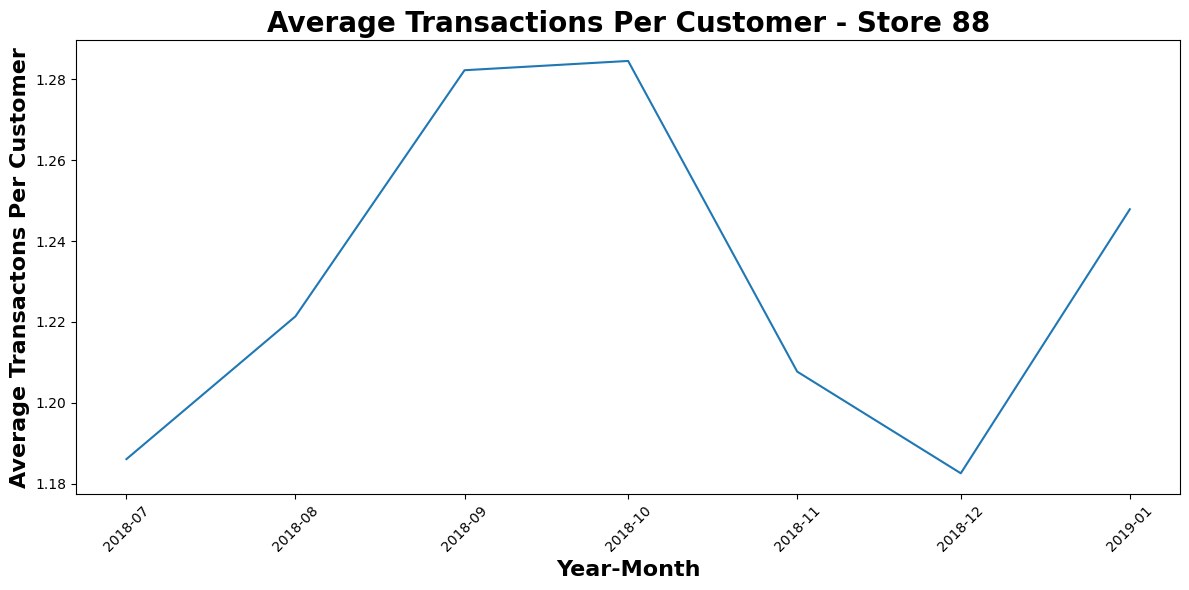

In [115]:
plt.figure(figsize=(12,6))

plt.plot(trial_store_88_transactions['YEAR MONTH'],
        trial_store_88_transactions['AVG_TXN_PER_CUSTOMER'])

plt.xticks(rotation=45)
plt.xlabel('Year-Month', fontsize=16, fontweight='bold')
plt.ylabel('Average Transactons Per Customer', fontsize=16, fontweight='bold')
plt.title('Average Transactions Per Customer - Store 88', fontsize=20, fontweight='bold')

plt.tight_layout()
plt.show()

In [116]:
combined_transactions_88 = pd.concat([trial_store_88_transactions, non_trial_stores_88_transactions])

In [117]:
pivot_transactions_88 = combined_transactions_88.pivot_table(
    index='YEAR MONTH',
    columns='STORE_NBR',
    values='AVG_TXN_PER_CUSTOMER'
)

In [118]:
corr_88_transactions = pivot_transactions_88.corr()[88].sort_values(ascending=False)
corr_88_transactions.head()

STORE_NBR
88     1.000000
24     0.838989
137    0.828816
272    0.802702
243    0.763044
Name: 88, dtype: float64

In [119]:
avg_transactions_88 = pivot_transactions_88.mean()

transactions_comparison_88 = pd.DataFrame({
    'correlation': corr_88_customers,
    'avg_customers': avg_transactions_88
}).sort_values('correlation', ascending=False)

transactions_comparison_88.head()

,correlation,avg_customers
STORE_NBR,,
88,1.000000,1.230332
237,0.947326,1.211761
14,0.942976,1.000000
178,0.939466,1.299306
35,0.899594,1.016740


#### Control Store selected for Trial Store 88 is 237, they have similar metrics and a high correlation values 

### Trial Store and Control Store pairs are (77,31), (86,155), and (88,237)

The results for trial stores 77 and 88 during the trial period show a significant difference in at least two of the three trial months but this is not the case for trial store 86. We can check with the client if the implementation of the trial was different in trial store 86 but overall, the trial shows a significant increase in sales. Now that we have finished our analysis, we can prepare our presentation to the Category Manager.

#### Trial Stores Performance: Monthly Sales Feb 2019 and On 

In [28]:
trial_stores = df[(df['STORE_NBR'] == 77) | (df['STORE_NBR'] == 86) | (df['STORE_NBR'] == 88)]
trial_period = trial_stores[(trial_stores['SALES_YEAR'] >= 2019) & (trial_stores['SALES_MONTH'] >= 2)]

trial_period_sales = trial_period.groupby(
    ['STORE_NBR','SALES_YEAR', 'SALES_MONTH']
)['TOT_SALES'].sum().reset_index()

trial_period_sales['YEAR MONTH'] = pd.to_datetime(
    trial_period_sales['SALES_YEAR'].astype(str) + '-' +
    trial_period_sales['SALES_MONTH'].astype(str) 
)

trial_period_sales = trial_period_sales.sort_values('YEAR MONTH')

In [29]:
trial_pivot_sales = trial_period_sales.pivot_table(
    index='YEAR MONTH',
    columns='STORE_NBR',
    values='TOT_SALES'
)

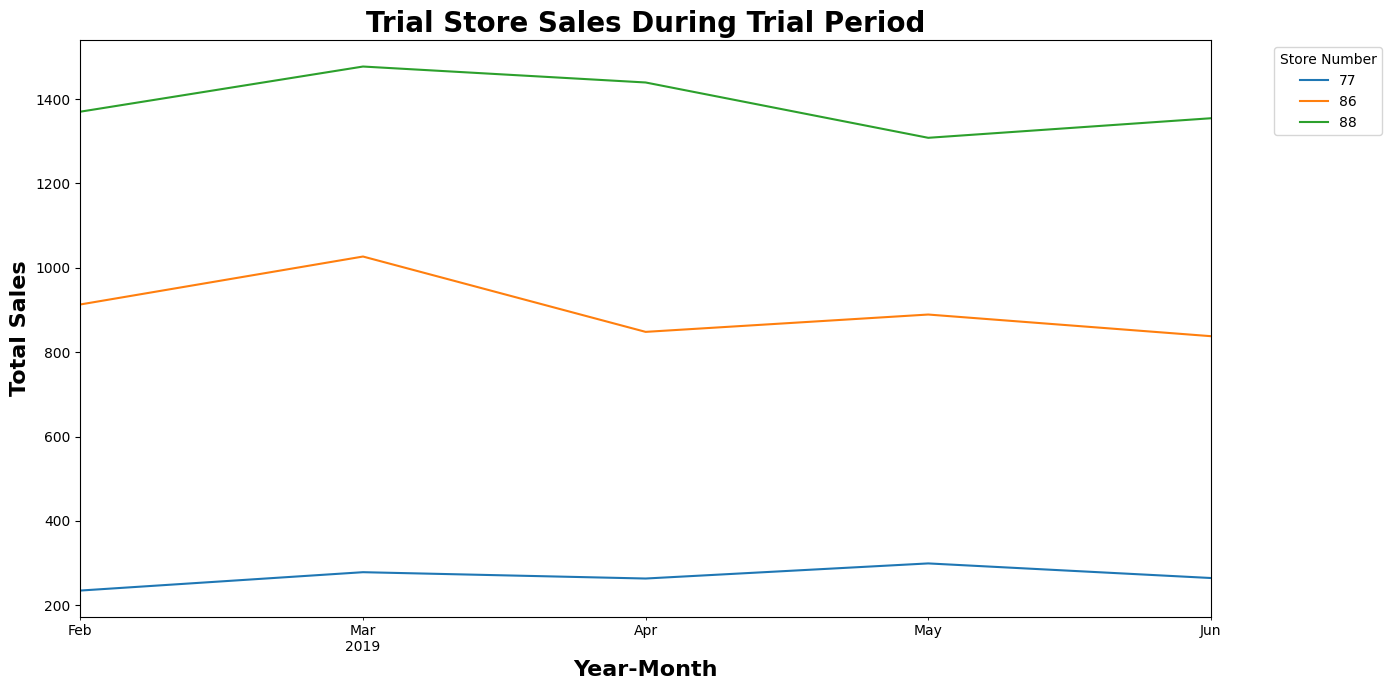

In [32]:
plt.figure(figsize=(14,7))

trial_pivot_sales.plot(ax=plt.gca())

plt.xlabel('Year-Month', fontsize=16, fontweight='bold')
plt.ylabel('Total Sales', fontsize=16, fontweight='bold')
plt.title('Trial Store Sales During Trial Period', fontsize=20, fontweight='bold')

plt.legend(title='Store Number', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()